In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

df_annotators = pd.read_csv("from_annotators.csv")
df_golden = pd.read_csv("hate_speech_gold_sample.csv")

print(df_annotators.shape)
print(df_golden.shape)

df_annotators.head()

(1000, 4)
(1000, 3)


,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,No,no,Yes
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",Yes,yes,Yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",No,no,Yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",No,no,Yes
4,Hate it jab test ata ho phr bh acha na ho -.-,Yes,yes,Yes


In [2]:
df_golden.head()

,Unnamed: 0,text,is_hate_speech
0,0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no
1,1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",no
2,2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no
3,3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",yes
4,4,Hate it jab test ata ho phr bh acha na ho -.-,yes


In [3]:
df_annotators.columns = df_annotators.columns.str.strip().str.lower()
df_golden.columns = df_golden.columns.str.strip().str.lower()

df_golden = df_golden.drop(columns=["unnamed: 0"], errors="ignore")


In [4]:
def normalize_label(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower()

for col in ["annotator_1", "annotator_2", "annotator_3"]:
    df_annotators[col] = df_annotators[col].apply(normalize_label)

df_golden["is_hate_speech"] = df_golden["is_hate_speech"].apply(normalize_label)

In [5]:
df = df_annotators.merge(
    df_golden,
    on="text",
    how="inner"
)

df = df.rename(columns={
    "is_hate_speech": "gold_label"
})

print(df.shape)
df.head()

(1000, 5)


,text,annotator_1,annotator_2,annotator_3,gold_label
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes,no
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",yes,yes,yes,no
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes,no
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes,yes
4,Hate it jab test ata ho phr bh acha na ho -.-,yes,yes,yes,yes


In [6]:
df.to_csv("merged_data.csv")

In [7]:
df = pd.read_csv("merged_data.csv")
# df.drop("Unnamed: 0	",axis=1,inplace=True)

In [8]:
df.isnull().sum()


,0
Unnamed: 0,0
text,1
annotator_1,0
annotator_2,0
annotator_3,0
gold_label,0


In [9]:
df = df.dropna(subset=[
    'text',"annotator_1", "annotator_2", "annotator_3", "gold_label"
])

df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,999.000000,999.000000
mean,113.905906,21.301301
std,59.951560,11.288897
min,13.000000,3.000000
25%,69.000000,13.000000
50%,108.000000,20.000000
75%,139.000000,26.500000
max,341.000000,63.000000


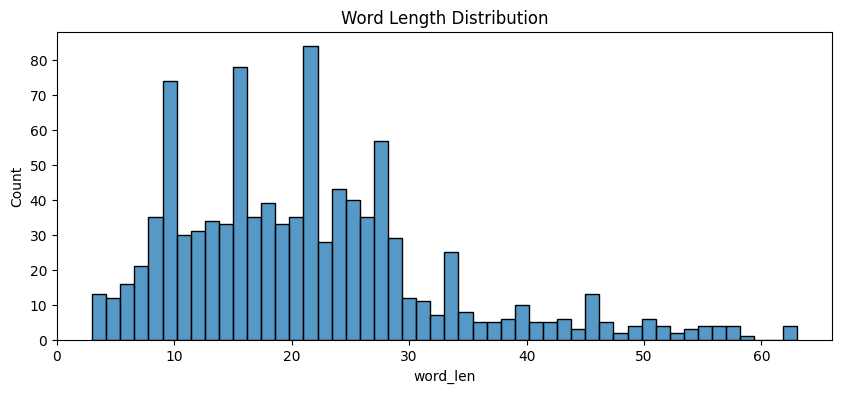

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(df["word_len"], bins=50)
plt.title("Word Length Distribution")
plt.show()

In [11]:
label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    print("\n", col)
    print(df[col].value_counts(normalize=True))


 annotator_1
annotator_1
no     0.527528
yes    0.472472
Name: proportion, dtype: float64

 annotator_2
annotator_2
no     0.620621
yes    0.379379
Name: proportion, dtype: float64

 annotator_3
annotator_3
yes    0.77978
no     0.22022
Name: proportion, dtype: float64

 gold_label
gold_label
no     0.707708
yes    0.292292
Name: proportion, dtype: float64


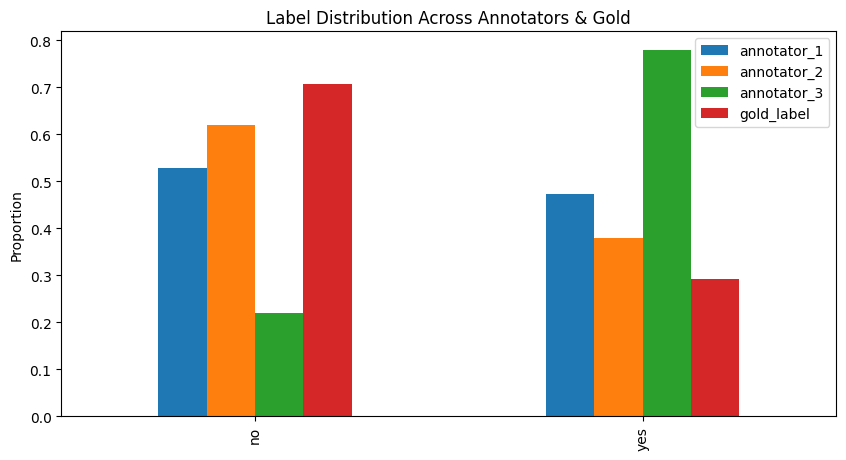

In [12]:
# Label distribution per annotator
label_dist = pd.DataFrame({
    col: df[col].value_counts(normalize=True)
    for col in label_cols
}).fillna(0)

label_dist.plot(kind="bar", figsize=(10,5))
plt.title("Label Distribution Across Annotators & Gold")
plt.ylabel("Proportion")
plt.show()

In [13]:
# Majority vote
df["majority_label"] = df[
    ["annotator_1", "annotator_2", "annotator_3"]
].mode(axis=1)[0]

In [14]:
df["num_yes"] = (
    (df["annotator_1"] == "yes").astype(int) +
    (df["annotator_2"] == "yes").astype(int) +
    (df["annotator_3"] == "yes").astype(int)
)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1,2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [15]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\u0900-\u097F\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(5)

,text,clean_text
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho


In [16]:
label_map = {"no": 0, "yes": 1}

for col in label_cols + ["majority_label"]:
    df[col + "_bin"] = df[col].map(label_map)

In [17]:
df["label_distribution"] = df.apply(
    lambda row: [
        row["annotator_1_bin"],
        row["annotator_2_bin"],
        row["annotator_3_bin"]
    ],
    axis=1
)

In [18]:
df["gold_vs_majority_mismatch"] = (
    df["gold_label_bin"] != df["majority_label_bin"]
).astype(int)

df["gold_vs_majority_mismatch"].value_counts(normalize=True)

,proportion
gold_vs_majority_mismatch,
0,0.684685
1,0.315315


In [19]:
final_cols = [
    "text",
    "clean_text",
    "annotator_1_bin",
    "annotator_2_bin",
    "annotator_3_bin",
    "gold_label_bin",
    "majority_label_bin",
    "disagreement"
]

final_df = df[final_cols]
final_df.head()

,text,clean_text,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin,majority_label_bin,disagreement
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and,0,0,1,0,0,1
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw,1,1,1,0,1,0
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...,0,0,1,0,0,1
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye,0,0,1,1,0,1
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho,1,1,1,1,1,0


In [20]:
LABEL_MAP = {
    "yes": 1,
    "no": 0
}

label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    df[col] = df[col].str.strip().str.lower()
    df[col + "_bin"] = df[col].map(LABEL_MAP)

In [21]:
df[label_cols + [c + "_bin" for c in label_cols]].head()

,annotator_1,annotator_2,annotator_3,gold_label,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin
0,no,no,yes,no,0,0,1,0
1,yes,yes,yes,no,1,1,1,0
2,no,no,yes,no,0,0,1,0
3,no,no,yes,yes,0,0,1,1
4,yes,yes,yes,yes,1,1,1,1


In [22]:
# Cohen’s Kappa pairwise

from sklearn.metrics import cohen_kappa_score

annotator_pairs = [
    ("annotator_1_bin", "annotator_2_bin"),
    ("annotator_1_bin", "annotator_3_bin"),
    ("annotator_2_bin", "annotator_3_bin"),
]

for a, b in annotator_pairs:
    kappa = cohen_kappa_score(df[a], df[b])
    print(f"Cohen Kappa ({a} vs {b}): {kappa:.4f}")


Cohen Kappa (annotator_1_bin vs annotator_2_bin): 0.7991
Cohen Kappa (annotator_1_bin vs annotator_3_bin): 0.2950
Cohen Kappa (annotator_2_bin vs annotator_3_bin): 0.2733


In [23]:
#fleiss kappa

from statsmodels.stats.inter_rater import fleiss_kappa

def fleiss_matrix(df, cols):
    matrix = []
    for _, row in df[cols].iterrows():
        counts = [0, 0]
        for val in row:
            counts[val] += 1
        matrix.append(counts)
    return np.array(matrix)

fk_matrix = fleiss_matrix(
    df,
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
)

fleiss_kappa(fk_matrix)


np.float64(0.4122237132047699)

In [24]:
!pip install krippendorff

In [25]:
# Krippendorff’s Alpha
import krippendorff

alpha = krippendorff.alpha(
    reliability_data=df[
        ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
    ].values.T,
    level_of_measurement="nominal"
)

alpha

np.float64(0.412419834755252)

In [26]:
from sklearn.metrics import confusion_matrix

for col in ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]:
    cm = confusion_matrix(df["gold_label_bin"], df[col])
    print(f"\nConfusion Matrix: Gold vs {col}")
    print(cm)


Confusion Matrix: Gold vs annotator_1_bin
[[450 257]
 [ 77 215]]

Confusion Matrix: Gold vs annotator_2_bin
[[527 180]
 [ 93 199]]

Confusion Matrix: Gold vs annotator_3_bin
[[202 505]
 [ 18 274]]


In [27]:
df["majority_label_bin"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].mode(axis=1)[0]

In [28]:
df["num_yes"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].sum(axis=1)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1, 2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [29]:
ambiguous_cases = df[df["disagreement"] == 1]

ambiguous_cases[
    ["text", "annotator_1", "annotator_2", "annotator_3"]
].head(10)

,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes
5,Ek dil ek jaan akal ke imitihaan kal KP ke rape aur sawing between two legs after rape honge justified due to cinematic liberty aaj toh Rajput ki ho gayi shaan urdu ki gulaam,no,no,yes
6,Aise logo se sakht nafrat karta hu Jo caste ko naam ke sath jod ke chaude hote h but real me vo piddu hote h,no,no,yes
8,I am very sorry to say saaf dil shilpa ke fans hiten ke dil mein kya hai woh bhi samjhte hain hadh hoti hai nafrat ki bhi,no,no,yes
14,Mehanat to school me copy karke likhne me b lagti hai fir illegal kyu? Atanki ko b lagti hai fir nafrat kyu? Paise lekar ghar ki aurato ka smman bech doge kya paise aur mehanat ke liye aap?,no,no,yes
15,"Ladla wo hay jo fard jurm kay bad bhi girftar nahi hota, money trail nahi deta aur saza nahi milti, 14 murder karta hay aur phansi nahi lagti.",no,no,yes
17,Sir ji ab ye possible nahi hai bahut nafrat hai dono or ab ek hi rasta hai sarhad ke lakir ko mita kar hi ye khatam ho sakta hai jinna sahab to mar gaye or neharu ji bhi ab fir se ek kartay hai do...,yes,no,yes
18,"Code phatta hai toh phatne do, Mujhe project se nafrat ho gayi hai, Mujhe development team se hatne do",no,no,yes


In [30]:
datasets = {
    "gold": df[["clean_text", "gold_label_bin"]],
    "annotator_1": df[["clean_text", "annotator_1_bin"]],
    "annotator_2": df[["clean_text", "annotator_2_bin"]],
    "annotator_3": df[["clean_text", "annotator_3_bin"]],
    "majority": df[["clean_text", "majority_label_bin"]],
}

## Base model

In [31]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.2 MB/s eta 0:00:00


In [32]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

import emoji

def extra_features(text):
    return [
        sum(1 for c in text if c in "!?"),
        sum(1 for c in text if c.isupper()),
        emoji.emoji_count(text)
    ]

X_extra = np.array(df["clean_text"].apply(extra_features).tolist())

X_tfidf = tfidf.fit_transform(df["clean_text"])
X = hstack([X_tfidf, X_extra])

models = {
    "svm": LinearSVC(),
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(n_estimators=200)
}

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []

for dataset_name, dataset in datasets.items():
    y = dataset.iloc[:, 1].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        p, r, f, _ = precision_recall_fscore_support(
            y_test, preds, average="binary"
        )

        results.append([
            dataset_name, model_name, acc, p, r, f
        ])

In [34]:
results_df = pd.DataFrame(
    results,
    columns=[
        "dataset",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

results_df

,dataset,model,accuracy,precision,recall,f1
0,gold,svm,0.680,0.440000,0.379310,0.407407
1,gold,logreg,0.740,0.636364,0.241379,0.350000
2,gold,rf,0.760,0.692308,0.310345,0.428571
3,annotator_1,svm,0.920,0.953488,0.872340,0.911111
4,annotator_1,logreg,0.910,0.952381,0.851064,0.898876
5,annotator_1,rf,0.925,1.000000,0.840426,0.913295
6,annotator_2,svm,0.995,1.000000,0.986842,0.993377
7,annotator_2,logreg,0.970,1.000000,0.921053,0.958904
8,annotator_2,rf,0.995,1.000000,0.986842,0.993377
9,annotator_3,svm,0.945,0.944785,0.987179,0.965517


In [35]:
results_df.groupby(["dataset", "model"]).mean()

accuracy  precision    recall        f1
dataset     model                                          
annotator_1 logreg     0.910   0.952381  0.851064  0.898876
            rf         0.925   1.000000  0.840426  0.913295
            svm        0.920   0.953488  0.872340  0.911111
annotator_2 logreg     0.970   1.000000  0.921053  0.958904
            rf         0.995   1.000000  0.986842  0.993377
            svm        0.995   1.000000  0.986842  0.993377
annotator_3 logreg     0.860   0.847826  1.000000  0.917647
            rf         0.945   0.950311  0.980769  0.965300
            svm        0.945   0.944785  0.987179  0.965517
gold        logreg     0.740   0.636364  0.241379  0.350000
            rf         0.760   0.692308  0.310345  0.428571
            svm        0.680   0.440000  0.379310  0.407407
majority    logreg     0.920   0.986667  0.831461  0.902439
            rf         0.930   1.000000  0.842697  0.914634
            svm        0.885   0.912500  0.820225  0.863905

## Neural networks

In [61]:
import os
import logging
import warnings

warnings.filterwarnings("ignore")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("tokenizers").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)


In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [63]:
# Neural networks

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 30000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

In [64]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense
)

def build_cnn():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, 128)(inp)
    x = Conv1D(128, 3, activation="relu")(x)
    x = GlobalMaxPooling1D()(x)
    out = Dense(1, activation="sigmoid")(x)
    model = Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [65]:
from tensorflow.keras.layers import LSTM, Bidirectional

def build_bilstm():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, 128)(inp)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1, activation="sigmoid")(x)
    model = Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [66]:
from tensorflow.keras.layers import Attention

def build_bilstm_attention():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(MAX_VOCAB, 128)(inp)
    lstm_out = Bidirectional(
        LSTM(64, return_sequences=True)
    )(x)
    attn = Attention()([lstm_out, lstm_out])
    pooled = GlobalMaxPooling1D()(attn)
    out = Dense(1, activation="sigmoid")(pooled)
    model = Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [76]:
import re

def hinglish_normalize(text):
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"http\S+", "", text)
    return text

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODELS = {
    "mbert": "bert-base-multilingual-cased",
    "xlmr": "xlm-roberta-base"
}

import torch

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.enc = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

from transformers import Trainer, TrainingArguments

def train_transformer(model_name, texts, labels, seed):
    torch.manual_seed(seed)

    tokenizer = AutoTokenizer.from_pretrained(
        MODELS[model_name],
        use_fast=True,
        local_files_only=True   # 🔒 FORCE CACHE
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODELS[model_name],
        num_labels=2,
        local_files_only=True   # 🔒 FORCE CACHE
    )

    dataset = TextDataset(texts, labels, tokenizer)

    args = TrainingArguments(
        output_dir=f"./tmp/{model_name}_{seed}",
        per_device_train_batch_size=8,
        num_train_epochs=3,
        seed=seed,
        logging_steps=500,
        report_to="none",
        save_strategy="no",
        eval_strategy="no"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset
    )

    trainer.train()
    return model, tokenizer

SEEDS = [42, 43, 44, 45, 46]


In [77]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_transformer(model, tokenizer, texts, labels):
    model.eval()
    model.to(device)

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    enc = {k: v.to(device) for k, v in enc.items()}
    labels = torch.tensor(labels).to(device)

    with torch.no_grad():
        outputs = model(**enc)
        preds = torch.argmax(outputs.logits, dim=1)

    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


In [78]:
ANNOTATION_SETS = {
    "gold": df["gold_label_bin"].values,
    "annotator_1": df["annotator_1_bin"].values,
    "annotator_2": df["annotator_2_bin"].values,
    "annotator_3": df["annotator_3_bin"].values,
    "majority": df["majority_label_bin"].values,
}

TEXTS = df["clean_text"].apply(hinglish_normalize).tolist()

In [79]:
results = []

for ann_name, ann_labels in ANNOTATION_SETS.items():
    for model_name in MODELS.keys():
        for seed in SEEDS:

            print(f"\nRunning: {model_name} | {ann_name} | seed={seed}")

            model, tokenizer = train_transformer(
                model_name=model_name,
                texts=TEXTS,
                labels=ann_labels,
                seed=seed
            )

            metrics = evaluate_transformer(
                model,
                tokenizer,
                TEXTS,
                ann_labels
            )

            results.append({
                "annotation": ann_name,
                "model": model_name,
                "seed": seed,
                "accuracy": metrics["accuracy"],
                "macro_f1": metrics["macro_f1"],
                "weighted_f1": metrics["weighted_f1"]
            })


Running: mbert | gold | seed=42
{'train_runtime': '67.04', 'train_samples_per_second': '44.71', 'train_steps_per_second': '5.594', 'train_loss': '0.5474', 'epoch': '3'}

Running: mbert | gold | seed=43
{'train_runtime': '64.97', 'train_samples_per_second': '46.13', 'train_steps_per_second': '5.772', 'train_loss': '0.5384', 'epoch': '3'}

Running: mbert | gold | seed=44
{'train_runtime': '64.97', 'train_samples_per_second': '46.13', 'train_steps_per_second': '5.772', 'train_loss': '0.522', 'epoch': '3'}

Running: mbert | gold | seed=45
{'train_runtime': '64.97', 'train_samples_per_second': '46.13', 'train_steps_per_second': '5.772', 'train_loss': '0.6147', 'epoch': '3'}

Running: mbert | gold | seed=46
{'train_runtime': '64.96', 'train_samples_per_second': '46.14', 'train_steps_per_second': '5.773', 'train_loss': '0.6139', 'epoch': '3'}

Running: xlmr | gold | seed=42
{'train_runtime': '67.95', 'train_samples_per_second': '44.1', 'train_steps_per_second': '5.519', 'train_loss': '0.6181

OSError: Unable to load vocabulary from file. Please check that the provided vocabulary is accessible and not corrupted.

In [71]:
results_df = pd.DataFrame(results)
results_df.head()

""


In [ ]:
def cv_star(values):
    values = np.array(values)
    return values.std(ddof=1) / values.mean()

cv_results = []

for (ann, model), group in results_df.groupby(["annotation", "model"]):
    cv_results.append({
        "annotation": ann,
        "model": model,
        "cv_star_macro_f1": cv_star(group["macro_f1"].values)
    })

cv_df = pd.DataFrame(cv_results)
cv_df

In [ ]:
model, tokenizer = train_transformer(
    model_name="mbert",
    texts=TEXTS[:200],
    labels=ANNOTATION_SETS["gold"][:200],
    seed=42
)


In [ ]:
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)
from lime.lime_text import LimeTextExplainer
import shap

def soft_label(row):
    counts = [0, 0]
    for a in ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]:
        counts[row[a]] += 1
    return np.array(counts) / sum(counts)

df["soft_label"] = df.apply(soft_label, axis=1)

def soft_metrics(pred, gold):
    return {
        "js": jensenshannon(pred, gold),
        "l1": np.sum(np.abs(pred - gold)),
        "l2": np.linalg.norm(pred - gold)
    }

def hard_eval(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }

def cv_star(scores):
    scores = np.array(scores)
    mean = scores.mean()
    std = scores.std(ddof=1)
    return std / mean if mean != 0 else 0

f1_scores = [0.91, 0.89, 0.92, 0.90, 0.88]
cv_star(f1_scores)

def delta(a, b):
    return abs(a - b)

explainer = LimeTextExplainer(class_names=["no", "yes"])

def lime_explain(model, tokenizer, text):
    def predict(texts):
        enc = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            logits = model(**enc).logits
        return torch.softmax(logits, dim=1).numpy()

    return explainer.explain_instance(text, predict)

def shap_explain(model, tokenizer, texts):
    explainer = shap.Explainer(
        model,
        tokenizer
    )
    return explainer(texts)

df["error"] = df["gold_label_bin"] != df["majority_label_bin"]

df[df["disagreement"] == 1][
    ["text", "annotator_1", "annotator_2", "annotator_3"]
].head(10)
